In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
sys.path.append(os.path.abspath("../.."))
from brain_reg_models import build_model
tf.get_logger().setLevel('ERROR')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

2026-03-24 00:47:20.320202: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-24 00:47:20.320414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-24 00:47:20.383414: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
FLOAT_MODEL_PATH = "../trained_weights/2p5d_dense_tf_best.h5"
# CROSS-SUBJECT test data (1BA001 MR -> 1BA005 CT)
MR_VOLUME_PATH = "./test_data/1BA001_mr.npy"
CT_VOLUME_PATH = "./test_data/1BA005_ct.npy"
MR_SEG_PATH = "./test_data/1BA001_mr_seg.npy"
CT_SEG_PATH = "./test_data/1BA005_ct_seg.npy"

OUTPUT_DIR = "./gpu_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

WINDOW_RADIUS = 3
N_STACK = 7
INPUT_HEIGHT = 112
INPUT_WIDTH = 96

print("Configuration:")
print(f"  Test data: CROSS-SUBJECT (1BA001 MR -> 1BA005 CT)")
print(f"  Model: GPU TensorFlow model")

Configuration:
  Test data: CROSS-SUBJECT (1BA001 MR -> 1BA005 CT)
  Model: GPU TensorFlow model


In [3]:
print("Loading TensorFlow model...")
model = build_model(FLOAT_MODEL_PATH, img_height=INPUT_HEIGHT, img_width=INPUT_WIDTH, window_radius=WINDOW_RADIUS)
print(f"Model loaded. Expected inputs: {[inp.name for inp in model.inputs]}")


Loading TensorFlow model...
[MODEL] Loading model from 2p5d_dense_tf_best.h5
[MODEL] Loaded model with 78 weight variables
[MODEL] flow_scale layer found (scale=0.10000000149011612)
Model loaded. Expected inputs: ['moving_stack', 'fixed_stack']


In [4]:
def extract_slice_stack(volume, axis, z, window_radius, target_size=(112, 96)):
    wr = window_radius
    if axis == 0:
        stack = volume[z-wr:z+wr+1]
    elif axis == 1:
        stack = volume[:, z-wr:z+wr+1, :].transpose(1, 0, 2)
    else:
        stack = volume[:, :, z-wr:z+wr+1].transpose(2, 0, 1)
    
    resized_stack = []
    for i in range(stack.shape[0]):
        resized = cv2.resize(stack[i], (target_size[1], target_size[0]), interpolation=cv2.INTER_LINEAR)
        resized_stack.append(resized)
    
    return np.ascontiguousarray(np.array(resized_stack))


def apply_flow_2d(image, flow):
    h, w = image.shape
    
    if flow.shape[1] != h or flow.shape[2] != w:
        flow_x = cv2.resize(flow[0], (w, h), interpolation=cv2.INTER_LINEAR)
        flow_y = cv2.resize(flow[1], (w, h), interpolation=cv2.INTER_LINEAR)
        scale_x = w / flow.shape[2]
        scale_y = h / flow.shape[1]
        flow_x = flow_x * scale_x
        flow_y = flow_y * scale_y
    else:
        flow_x = flow[0]
        flow_y = flow[1]
    
    y_coords, x_coords = np.mgrid[0:h, 0:w].astype(np.float32)
    new_x = x_coords + flow_x
    new_y = y_coords + flow_y
    warped = cv2.remap(image.astype(np.float32), new_x, new_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    return warped


def apply_flow_2d_nearest(image, flow):
    h, w = image.shape
    
    if flow.shape[1] != h or flow.shape[2] != w:
        flow_x = cv2.resize(flow[0], (w, h), interpolation=cv2.INTER_LINEAR)
        flow_y = cv2.resize(flow[1], (w, h), interpolation=cv2.INTER_LINEAR)
        scale_x = w / flow.shape[2]
        scale_y = h / flow.shape[1]
        flow_x = flow_x * scale_x
        flow_y = flow_y * scale_y
    else:
        flow_x = flow[0]
        flow_y = flow[1]
    
    y_coords, x_coords = np.mgrid[0:h, 0:w].astype(np.float32)
    new_x = x_coords + flow_x
    new_y = y_coords + flow_y
    warped = cv2.remap(image.astype(np.float32), new_x, new_y, cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT)
    return warped.astype(np.float32)


def plot_quiver(ax, flow, step=4):
    h, w = flow.shape[1], flow.shape[2]
    y, x = np.mgrid[0:h:step, 0:w:step]
    fx = flow[0, ::step, ::step]
    fy = flow[1, ::step, ::step]
    ax.imshow(np.zeros((h, w)), cmap='gray', alpha=0)
    ax.quiver(x, y, fx, fy, color='red', angles='xy', scale_units='xy', scale=1, headwidth=3, headlength=4, alpha=0.8)
    ax.invert_yaxis()


def seg_to_onehot(seg, labels=[2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]):
    onehot = np.zeros(seg.shape + (len(labels),), dtype=np.float32)
    for i, lbl in enumerate(labels):
        onehot[..., i] = (seg == lbl).astype(np.float32)
    return onehot


def compute_dice(pred_seg, gt_seg, labels=[2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]):
    dice_scores = []
    for lbl in labels:
        pred_mask = (pred_seg == lbl).astype(np.float32)
        gt_mask = (gt_seg == lbl).astype(np.float32)
        intersection = (pred_mask * gt_mask).sum()
        union = pred_mask.sum() + gt_mask.sum()
        if union == 0:
            dice_scores.append(1.0)
        else:
            dice_scores.append(2.0 * intersection / union)
    return np.mean(dice_scores)


def run_gpu_inference(moving_stack, fixed_stack):
    # Prepare inputs in TensorFlow format: (B, H, W, C)
    moving_input = moving_stack.transpose(1, 2, 0)[np.newaxis, ...].astype(np.float32)
    fixed_input = fixed_stack.transpose(1, 2, 0)[np.newaxis, ...].astype(np.float32)
    
    start = time.time()
    flow = model.predict([moving_input, fixed_input], verbose=0)
    duration = time.time() - start
    
    if len(flow.shape) == 4:
        flow = flow[0]
        if flow.shape[-1] == 2:
            flow = flow.transpose(2, 0, 1)
    
    return flow, duration


In [5]:
moving_vol = np.load(MR_VOLUME_PATH).astype(np.float32)
fixed_vol = np.load(CT_VOLUME_PATH).astype(np.float32)

try:
    moving_seg = np.load(MR_SEG_PATH).astype(np.float32)
    fixed_seg = np.load(CT_SEG_PATH).astype(np.float32)
    has_seg = True
except:
    has_seg = False
    moving_seg = np.zeros_like(moving_vol)
    fixed_seg = np.zeros_like(fixed_vol)
    print("Segmentation maps not found, skipping Dice evaluation.")

print(f"Moving: {moving_vol.shape}, range [{moving_vol.min():.3f}, {moving_vol.max():.3f}]")
print(f"Fixed: {fixed_vol.shape}, range [{fixed_vol.min():.3f}, {fixed_vol.max():.3f}]")
if has_seg:
    print(f"Moving Seg: {moving_seg.shape}, labels: {np.unique(moving_seg)}")
    print(f"Fixed Seg: {fixed_seg.shape}, labels: {np.unique(fixed_seg)}")


Moving: (176, 208, 192), range [-1.000, 1.000]
Fixed: (176, 208, 192), range [-1.000, 1.000]
Moving Seg: (176, 208, 192), labels: [ 0.  2.  3.  4.  5.  7.  8. 10. 11. 12. 13. 14. 15. 16. 17. 18. 24. 26.
 28.]
Fixed Seg: (176, 208, 192), labels: [ 0.  2.  3.  4.  5.  7.  8. 10. 11. 12. 13. 14. 15. 16. 17. 18. 24. 26.
 28.]



INFERENCE VERIFICATION
Inference time: 1546.49 ms
Flow shape: (2, 112, 96)
Flow range: [-3.6947, 1.2581]
Flow mean: -1.0788, std: 0.7972



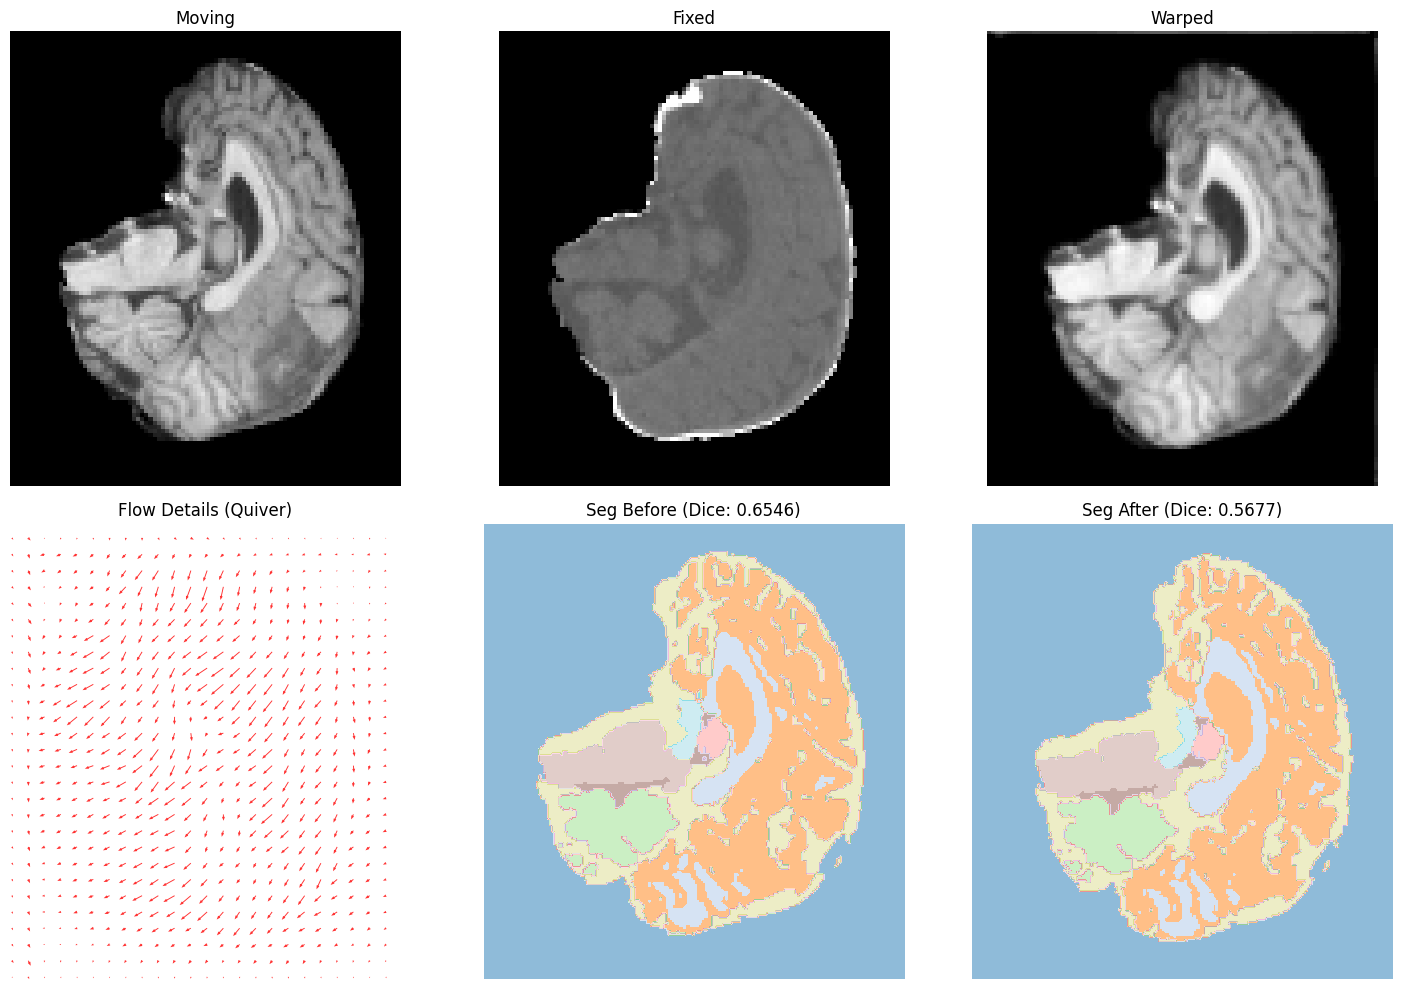

In [6]:
z_center = moving_vol.shape[0] // 2
moving_stack = extract_slice_stack(moving_vol, 0, z_center, WINDOW_RADIUS)
fixed_stack = extract_slice_stack(fixed_vol, 0, z_center, WINDOW_RADIUS)
moving_seg_center = moving_seg[z_center] if has_seg else None
fixed_seg_center = fixed_seg[z_center] if has_seg else None

flow, inf_time = run_gpu_inference(moving_stack, fixed_stack)

print("\n" + "="*70)
print("INFERENCE VERIFICATION")
print("="*70)
print(f"Inference time: {inf_time*1000:.2f} ms")
print(f"Flow shape: {flow.shape}")
print(f"Flow range: [{flow.min():.4f}, {flow.max():.4f}]")
print(f"Flow mean: {flow.mean():.4f}, std: {flow.std():.4f}")

print("="*70 + "\n")

center_idx = N_STACK // 2
moving_center = moving_stack[center_idx]
fixed_center = fixed_stack[center_idx]
warped = apply_flow_2d(moving_center, flow)

if has_seg:
    warped_seg = apply_flow_2d_nearest(moving_seg_center, flow)
    dice_before = compute_dice(moving_seg_center, fixed_seg_center)
    dice_after = compute_dice(warped_seg, fixed_seg_center)
else:
    warped_seg = np.zeros_like(moving_center)
    dice_before = 0.0
    dice_after = 0.0

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(moving_center, cmap='gray')
axes[0, 0].set_title('Moving')
axes[0, 0].axis('off')

axes[0, 1].imshow(fixed_center, cmap='gray')
axes[0, 1].set_title('Fixed')
axes[0, 1].axis('off')

axes[0, 2].imshow(warped, cmap='gray')
axes[0, 2].set_title('Warped')
axes[0, 2].axis('off')

plot_quiver(axes[1, 0], flow, step=4)
axes[1, 0].set_title('Flow Details (Quiver)')
axes[1, 0].axis('off')

if has_seg:
    axes[1, 1].imshow(moving_seg_center, cmap='tab20', alpha=0.5)
    axes[1, 1].set_title(f'Seg Before (Dice: {dice_before:.4f})')
else:
    diff_before = np.abs(moving_center - fixed_center)
    axes[1, 1].imshow(diff_before, cmap='hot')
    axes[1, 1].set_title(f'Diff Before (MAE: {diff_before.mean():.4f})')
axes[1, 1].axis('off')

if has_seg:
    axes[1, 2].imshow(warped_seg, cmap='tab20', alpha=0.5)
    axes[1, 2].set_title(f'Seg After (Dice: {dice_after:.4f})')
else:
    diff_after = np.abs(warped - fixed_center)
    axes[1, 2].imshow(diff_after, cmap='hot')
    axes[1, 2].set_title(f'Diff After (MAE: {diff_after.mean():.4f})')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/single_slice.png", dpi=150)
plt.show()


In [7]:
def infer_full_volume(moving_vol, fixed_vol, moving_seg=None, axis=0):
    D = moving_vol.shape[axis]
    wr = WINDOW_RADIUS
    
    if axis == 0:
        orig_h, orig_w = moving_vol.shape[1], moving_vol.shape[2]
    elif axis == 1:
        orig_h, orig_w = moving_vol.shape[0], moving_vol.shape[2]
    else:
        orig_h, orig_w = moving_vol.shape[0], moving_vol.shape[1]
    
    warped_volume = np.zeros_like(moving_vol)
    if moving_seg is not None:
        warped_seg_volume = np.zeros_like(moving_seg)
    else:
        warped_seg_volume = None
        
    flow_volume = []
    inference_times = []
    
    start_total = time.time()
    
    for z in range(wr, D - wr):
        moving_stack = extract_slice_stack(moving_vol, axis, z, wr)
        fixed_stack = extract_slice_stack(fixed_vol, axis, z, wr)
        
        flow, inf_time = run_gpu_inference(moving_stack, fixed_stack)
        inference_times.append(inf_time)
        flow_volume.append(flow)
        
        if axis == 0:
            moving_center = moving_vol[z]
            if moving_seg is not None: moving_seg_center = moving_seg[z]
        elif axis == 1:
            moving_center = moving_vol[:, z, :]
            if moving_seg is not None: moving_seg_center = moving_seg[:, z, :]
        else:
            moving_center = moving_vol[:, :, z]
            if moving_seg is not None: moving_seg_center = moving_seg[:, :, z]
        
        warped_slice = apply_flow_2d(moving_center, flow)
        if moving_seg is not None:
            warped_seg_slice = apply_flow_2d_nearest(moving_seg_center, flow)
        
        if axis == 0:
            warped_volume[z] = warped_slice
            if moving_seg is not None: warped_seg_volume[z] = warped_seg_slice
        elif axis == 1:
            warped_volume[:, z, :] = warped_slice
            if moving_seg is not None: warped_seg_volume[:, z, :] = warped_seg_slice
        else:
            warped_volume[:, :, z] = warped_slice
            if moving_seg is not None: warped_seg_volume[:, :, z] = warped_seg_slice
        
        if (z - wr + 1) % 10 == 0:
            print(f"Processed {z - wr + 1}/{D - 2*wr} (avg {np.mean(inference_times)*1000:.2f} ms/slice)")
    
    total_time = time.time() - start_total
    
    print(f"Total time: {total_time:.2f} s")
    print(f"Average: {np.mean(inference_times)*1000:.2f} ms/slice")
    print(f"Throughput: {(D - 2*wr) / total_time:.2f} slices/s")
    
    return warped_volume, np.array(flow_volume), inference_times, warped_seg_volume

warped_vol, flow_vol, inf_times, warped_seg_vol = infer_full_volume(moving_vol, fixed_vol, moving_seg if has_seg else None, axis=0)


Processed 10/170 (avg 38.40 ms/slice)
Processed 20/170 (avg 40.45 ms/slice)
Processed 30/170 (avg 40.16 ms/slice)
Processed 40/170 (avg 39.75 ms/slice)
Processed 50/170 (avg 39.75 ms/slice)
Processed 60/170 (avg 39.60 ms/slice)
Processed 70/170 (avg 39.64 ms/slice)
Processed 80/170 (avg 39.17 ms/slice)
Processed 90/170 (avg 38.85 ms/slice)
Processed 100/170 (avg 38.55 ms/slice)
Processed 110/170 (avg 38.45 ms/slice)
Processed 120/170 (avg 38.37 ms/slice)
Processed 130/170 (avg 38.52 ms/slice)
Processed 140/170 (avg 38.87 ms/slice)
Processed 150/170 (avg 39.01 ms/slice)
Processed 160/170 (avg 39.26 ms/slice)
Processed 170/170 (avg 39.57 ms/slice)
Total time: 7.40 s
Average: 39.57 ms/slice
Throughput: 22.97 slices/s


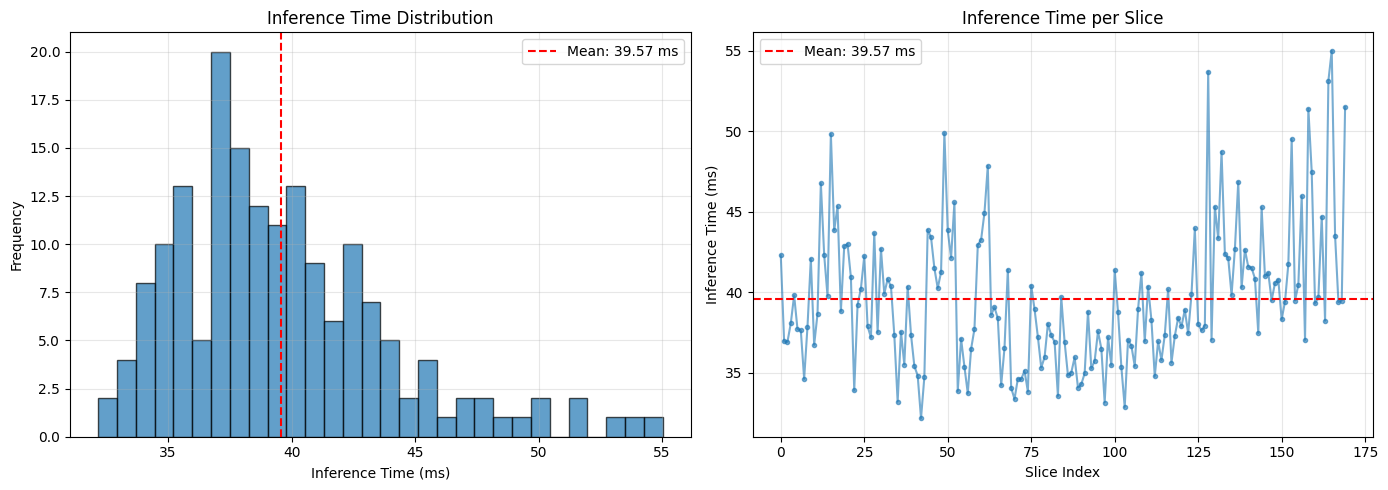

Slices: 170
Mean: 39.57 ms
Std: 4.36 ms
Min: 32.17 ms
Max: 55.02 ms


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.array(inf_times) * 1000, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(inf_times) * 1000, color='red', linestyle='--', label=f'Mean: {np.mean(inf_times)*1000:.2f} ms')
axes[0].set_xlabel('Inference Time (ms)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Inference Time Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(np.array(inf_times) * 1000, marker='o', markersize=3, alpha=0.6)
axes[1].axhline(np.mean(inf_times) * 1000, color='red', linestyle='--', label=f'Mean: {np.mean(inf_times)*1000:.2f} ms')
axes[1].set_xlabel('Slice Index')
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_title('Inference Time per Slice')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/performance.png", dpi=150)
plt.show()

print(f"Slices: {len(inf_times)}")
print(f"Mean: {np.mean(inf_times)*1000:.2f} ms")
print(f"Std: {np.std(inf_times)*1000:.2f} ms")
print(f"Min: {np.min(inf_times)*1000:.2f} ms")
print(f"Max: {np.max(inf_times)*1000:.2f} ms")

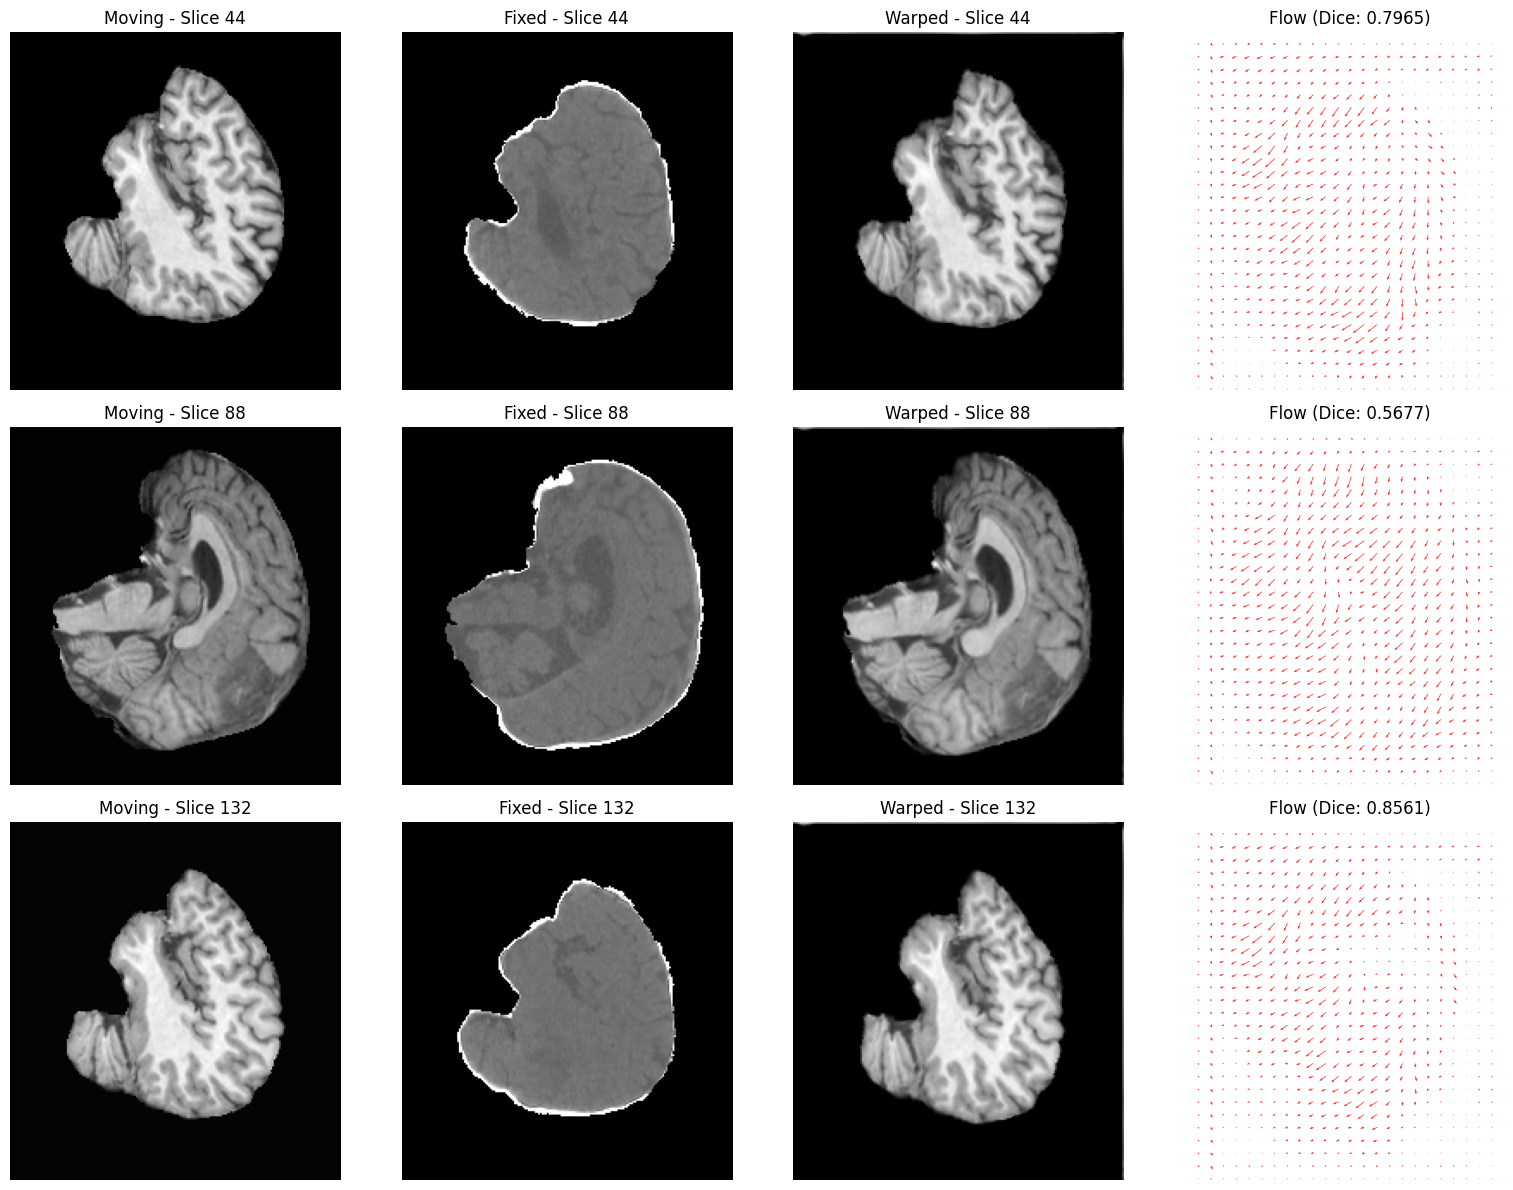

In [9]:
slice_indices = [moving_vol.shape[0]//4, moving_vol.shape[0]//2, 3*moving_vol.shape[0]//4]

fig, axes = plt.subplots(len(slice_indices), 4, figsize=(16, 4*len(slice_indices)))

for i, z in enumerate(slice_indices):
    if WINDOW_RADIUS <= z < moving_vol.shape[0] - WINDOW_RADIUS:
        axes[i, 0].imshow(moving_vol[z], cmap='gray')
        axes[i, 0].set_title(f'Moving - Slice {z}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(fixed_vol[z], cmap='gray')
        axes[i, 1].set_title(f'Fixed - Slice {z}')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(warped_vol[z], cmap='gray')
        axes[i, 2].set_title(f'Warped - Slice {z}')
        axes[i, 2].axis('off')
        
        if has_seg:
            vol_z_flow = flow_vol[z - WINDOW_RADIUS]
            dice_score = compute_dice(warped_seg_vol[z], fixed_seg[z])
            plot_quiver(axes[i, 3], vol_z_flow, step=4)
            axes[i, 3].set_title(f'Flow (Dice: {dice_score:.4f})')
            axes[i, 3].axis('off')
        else:
            diff = np.abs(warped_vol[z] - fixed_vol[z])
            im = axes[i, 3].imshow(diff, cmap='hot')
            axes[i, 3].set_title(f'Diff (MAE: {diff.mean():.4f})')
            axes[i, 3].axis('off')
            plt.colorbar(im, ax=axes[i, 3])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/volume_results.png", dpi=150)
plt.show()


In [10]:
np.save(f"{OUTPUT_DIR}/warped_volume.npy", warped_vol)
np.save(f"{OUTPUT_DIR}/flow_volume.npy", flow_vol)

import json
results = {
    'mean_time_ms': float(np.mean(inf_times) * 1000),
    'std_time_ms': float(np.std(inf_times) * 1000),
    'throughput_slices_per_sec': float(len(inf_times) / sum(inf_times)),
    'total_slices': len(inf_times),
}

with open(f"{OUTPUT_DIR}/results.json", 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {OUTPUT_DIR}/")

Results saved to ./gpu_results/


In [11]:
print("Done")

Done
